# Playground: wave packets, free propagation, and Rabi

Three short demos for learning wave functions and Schrödinger dynamics.
Converted from `Matrixandode.py` into a notebook for easier reading.


## 0. Setup


In [1]:
import sys
from pathlib import Path

# Make quantum/_common importable whether the kernel cwd is the repo root
# or the subject folder.
_here = Path.cwd().resolve()
for candidate in (_here, _here.parent, _here.parent.parent):
    if (candidate / "_common").is_dir():
        sys.path.insert(0, str(candidate))
        break

import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.figsize": (8, 4.5),
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
})

from scipy.integrate import solve_ivp
print("Ready.")


Ready.


## 1. Gaussian wave packet

A normalized Gaussian $\psi(x)$ and its probability density $|\psi(x)|^2$.


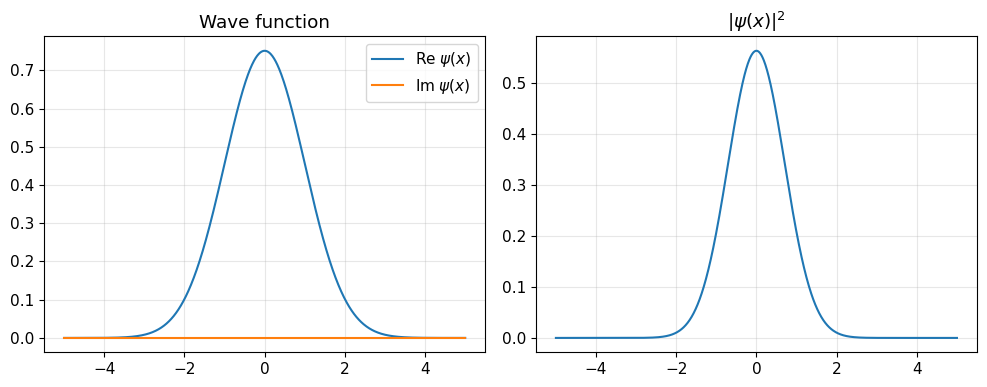

In [2]:
x = np.linspace(-5, 5, 1000)
dx = x[1] - x[0]
sigma = 1.0
psi = np.exp(-x**2 / (2 * sigma**2)).astype(complex)
psi /= np.sqrt(np.sum(np.abs(psi) ** 2) * dx)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(x, psi.real, label=r"Re $\psi(x)$")
axes[0].plot(x, psi.imag, label=r"Im $\psi(x)$")
axes[0].set_title("Wave function")
axes[0].legend()
axes[1].plot(x, np.abs(psi) ** 2)
axes[1].set_title(r"$|\psi(x)|^2$")
plt.tight_layout()
plt.show()


## 2. Free propagation (split-step FFT)

Evolve a moving Gaussian under $H = p^2/2m$ by multiplying by the free phase
$e^{-i \hbar k^2 t / 2m}$ in momentum space.


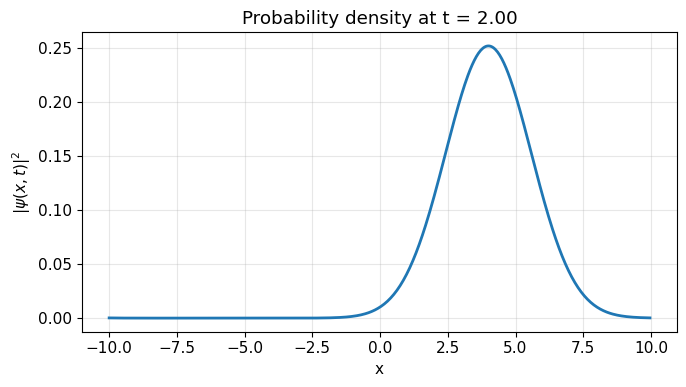

In [3]:
N, L = 512, 20.0
x = np.linspace(-L / 2, L / 2, N, endpoint=False)
dx = x[1] - x[0]
k = 2 * np.pi * np.fft.fftfreq(N, d=dx)
hbar, m = 1.0, 1.0

sigma, k0 = 1.0, 2.0
psi = np.exp(-x**2 / (2 * sigma**2)) * np.exp(1j * k0 * x)
psi = psi / np.sqrt(np.sum(np.abs(psi) ** 2) * dx)

dt, steps = 0.01, 200
phase = np.exp(-1j * (hbar * k**2 / (2 * m)) * dt)
for _ in range(steps):
    psi = np.fft.ifft(np.fft.fft(psi) * phase)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(x, np.abs(psi) ** 2, lw=2)
ax.set_title(f"Probability density at t = {steps * dt:.2f}")
ax.set_xlabel("x")
ax.set_ylabel(r"$|\psi(x,t)|^2$")
plt.tight_layout()
plt.show()


## 3. Rabi oscillations (ODE form)

Integrate the two-level Schrödinger equation with `scipy.integrate.solve_ivp`.
For the cleaner operator form see
`../04_quantum_electronics/01_rabi_oscillations.ipynb`.


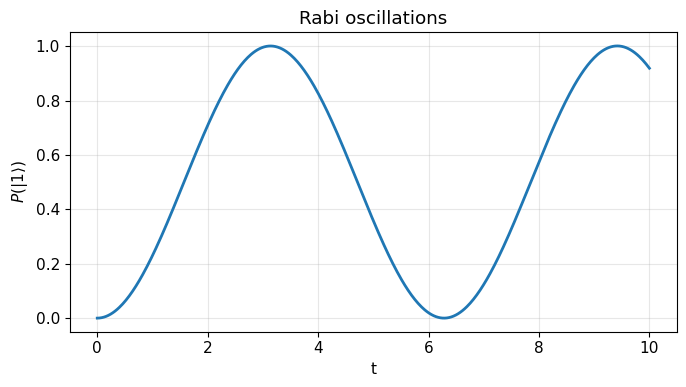

In [4]:
omega = 1.0

def schrodinger_2level(t, y):
    c0 = y[0] + 1j * y[1]
    c1 = y[2] + 1j * y[3]
    dc0 = -1j * (omega / 2) * c1
    dc1 = -1j * (omega / 2) * c0
    return [dc0.real, dc0.imag, dc1.real, dc1.imag]

sol = solve_ivp(schrodinger_2level, (0, 10), [1, 0, 0, 0],
                t_eval=np.linspace(0, 10, 500))
p1 = np.abs(sol.y[2] + 1j * sol.y[3]) ** 2

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(sol.t, p1, lw=2)
ax.set_xlabel("t")
ax.set_ylabel(r"$P(|1\rangle)$")
ax.set_title("Rabi oscillations")
plt.tight_layout()
plt.show()
